<a href="https://colab.research.google.com/github/MarineGuell/PlumID/blob/main/PlumeID_Generative_mod%C3%A8le_(Th%C3%A9o).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==== Cellule 1 : Imports et configuration ====

import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt

# Configuration du device (GPU si disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Répertoires principaux (à adapter selon votre machine)
DATASET_DIR = "/content/drive/MyDrive/Plumes_ID/Plumes_ID_Data"
CHECKPOINT_DIR = "/content/drive/MyDrive/Plumes_ID/checkpoints"
GENERATED_DIR = "/content/drive/MyDrive/Plumes_ID/generated_feathers"

Freq_episode_save = 500

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(GENERATED_DIR, exist_ok=True)

# Hyperparamètres globaux
IMAGE_SIZE = 64          # Résolution d'entraînement (64x64)
BATCH_SIZE = 16
NUM_EPOCHS = 4000          # À augmenter pour un vrai entraînement
LEARNING_RATE = 2e-4
TIMESTEPS = 1000          # Nombre d'étapes de diffusion (schedule de bruit)

torch.manual_seed(42)
if device.type == "cuda":
    torch.cuda.manual_seed_all(42)



In [ ]:
import os

if os.path.exists('/content/drive'):
    print('Google Drive is mounted correctly.')
else:
    print('Google Drive is NOT mounted.')


Google Drive is mounted correctly.


In [ ]:

path = "/content/drive/MyDrive/Plumes_ID/Plumes_ID_Data"
print(os.listdir(path))

['anseriformes_anas_platyrhynchos_00019.jpg', 'anseriformes_anas_platyrhynchos_00040.jpg', 'anseriformes_anas_platyrhynchos_00132.jpg', 'anseriformes_anas_platyrhynchos_00008.jpg', 'anseriformes_anas_platyrhynchos_00090.jpg', 'anseriformes_anas_platyrhynchos_00079.jpg', 'anseriformes_anas_platyrhynchos_00032.jpg', 'anseriformes_anas_platyrhynchos_00124.jpg', 'anseriformes_anas_platyrhynchos_00077.jpg', 'anseriformes_anas_platyrhynchos_00031.jpg', 'anseriformes_anas_platyrhynchos_00055.jpg', 'anseriformes_anas_platyrhynchos_00027.jpg', 'anseriformes_anas_platyrhynchos_00072.jpg', 'anseriformes_anas_platyrhynchos_00173.jpg', 'anseriformes_anas_platyrhynchos_00064.jpg', 'anseriformes_anas_platyrhynchos_00130.jpg', 'anseriformes_anas_platyrhynchos_00074.jpg', 'anseriformes_anas_platyrhynchos_00136.jpg', 'anseriformes_anas_platyrhynchos_00088.jpg', 'anseriformes_anas_platyrhynchos_00003.jpg', 'anseriformes_anas_platyrhynchos_00046.jpg', 'anseriformes_anas_platyrhynchos_00004.jpg', 'anserifo

In [ ]:
# ==== Cellule 2 : Dataset et DataLoader ====

# Transformations appliquées aux images de plumes :
# - Redimensionnement
# - Recadrage / centrage
# - Conversion en tenseur
# - Normalisation dans [-1, 1] (utile pour les modèles génératifs)
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.CenterCrop((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # [0,1] -> [-1,1]
])

# Remove any .ipynb_checkpoints directories that might interfere with ImageFolder
checkpoint_path = os.path.join(DATASET_DIR, '.ipynb_checkpoints')
if os.path.exists(checkpoint_path) and os.path.isdir(checkpoint_path):
    try:
        import shutil
        shutil.rmtree(checkpoint_path)
        print(f"Removed interfering directory: {checkpoint_path}")
    except Exception as e:
        print(f"Error removing {checkpoint_path}: {e}")

# Dataset basé sur une structure de dossiers :
# DATASET_DIR/
#   ├── type_1/
#   │     ├── img1.jpg
#   │     └── img2.jpg
#   └── type_2/
#         ├── img3.jpg
#         └── img4.jpg
#
# Chaque sous-dossier peut représenter un "type" de plume / espèce / motif
# pour permettre un conditionnement par classe.

feather_dataset = datasets.ImageFolder(
    root=DATASET_DIR,
    transform=transform
)

# Si le dataset est vide ou introuvable, il faudra adapter DATASET_DIR
if len(feather_dataset) == 0:
    print("⚠️  Le dataset est vide. Vérifiez le chemin DATASET_DIR et la structure des dossiers.")

num_classes = len(feather_dataset.classes) if len(feather_dataset.classes) > 0 else 1

feather_dataloader = DataLoader(
    feather_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    """
    Encodage sinusoidal du timestep (comme dans les transformers).
    Permet d'injecter l'information temporelle (niveau de bruit) dans le réseau.
    """
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor):
        half_dim = self.dim // 2
        # Formule classique de positional encoding des Transformers
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t.float().unsqueeze(1) * emb.unsqueeze(0)
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
        return emb


class SelfAttentionBlock(nn.Module):
    """
    Bloc Self-Attention 2D pour images.
    On aplatit les features spatiales en séquence, applique Multi-Head Attention,
    puis on remodèle au format image.
    """
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Linear(channels, channels * 3)
        self.proj = nn.Linear(channels, channels)

    def forward(self, x):
        # x : (B, C, H, W)
        b, c, h, w = x.shape
        x_in = x

        x = self.norm(x)
        x = x.view(b, c, h * w).transpose(1, 2)  # (B, HW, C)

        qkv = self.qkv(x)  # (B, HW, 3C)
        q, k, v = qkv.chunk(3, dim=-1)

        # Découpage en têtes
        head_dim = c // self.num_heads
        q = q.view(b, h * w, self.num_heads, head_dim).transpose(1, 2)  # (B, heads, HW, head_dim)
        k = k.view(b, h * w, self.num_heads, head_dim).transpose(1, 2)
        v = v.view(b, h * w, self.num_heads, head_dim).transpose(1, 2)

        scale = head_dim ** -0.5
        attn = (q @ k.transpose(-2, -1)) * scale  # (B, heads, HW, HW)
        attn = attn.softmax(dim=-1)

        out = attn @ v  # (B, heads, HW, head_dim)
        out = out.transpose(1, 2).contiguous().view(b, h * w, c)
        out = self.proj(out)  # (B, HW, C)

        out = out.transpose(1, 2).view(b, c, h, w)
        return x_in + out  # Résiduel


class ResidualBlock(nn.Module):
    """
    Bloc résiduel simple avec GroupNorm + Conv, incluant l'encodage temporel et éventuellement un encodage de classe.
    """
    def __init__(self, in_channels, out_channels, time_emb_dim, class_emb_dim=0):
        super().__init__()

        self.time_mlp = nn.Linear(time_emb_dim, out_channels)
        self.class_emb_dim = class_emb_dim
        if class_emb_dim > 0:
            self.class_mlp = nn.Linear(class_emb_dim, out_channels)
        else:
            self.class_mlp = None

        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        )

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, t_emb, c_emb=None):
        h = self.block1(x)

        # Ajout de l'encodage temporel
        t_out = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + t_out

        # Ajout de l'encodage de classe (optionnel)
        if self.class_mlp is not None and c_emb is not None:
            c_out = self.class_mlp(c_emb).unsqueeze(-1).unsqueeze(-1)
            h = h + c_out

        h = self.block2(h)
        return h + self.shortcut(x)


class UNetWithAttention(nn.Module):
    """
    U-Net simplifié pour diffusion, incluant des blocs d'attention type Transformer.
    Le modèle prend en entrée :
      - x : image bruitée
      - t : timestep de diffusion
      - y : étiquette de classe (optionnelle) pour conditionner la génération
    """
    def __init__(self, img_channels=3, base_channels=64, time_emb_dim=256, num_classes=1):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(time_emb_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        # Embedding de classe pour conditionnement (type de plume / espèce)
        self.num_classes = num_classes
        if num_classes > 1:
            self.class_embedding = nn.Embedding(num_classes, time_emb_dim)
        else:
            self.class_embedding = None

        # Initial convolution to project img_channels to base_channels
        self.initial_conv = nn.Conv2d(img_channels, base_channels, kernel_size=3, padding=1)

        # Encoder
        self.enc1 = ResidualBlock(base_channels, base_channels, time_emb_dim, time_emb_dim if num_classes > 1 else 0)
        self.enc2 = ResidualBlock(base_channels, base_channels * 2, time_emb_dim, time_emb_dim if num_classes > 1 else 0)
        self.enc3 = ResidualBlock(base_channels * 2, base_channels * 4, time_emb_dim, time_emb_dim if num_classes > 1 else 0)

        self.down1 = nn.Conv2d(base_channels, base_channels, 4, 2, 1)
        self.down2 = nn.Conv2d(base_channels * 2, base_channels * 2, 4, 2, 1)

        # Bottleneck avec Self-Attention (comportement type Transformer)
        self.bot1 = ResidualBlock(base_channels * 4, base_channels * 4, time_emb_dim, time_emb_dim if num_classes > 1 else 0)
        self.attn = SelfAttentionBlock(base_channels * 4)
        self.bot2 = ResidualBlock(base_channels * 4, base_channels * 4, time_emb_dim, time_emb_dim if num_classes > 1 else 0)

        # Decoder
        self.up1 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 4, 2, 1)
        self.dec1 = ResidualBlock(base_channels * 4, base_channels * 2, time_emb_dim, time_emb_dim if num_classes > 1 else 0)

        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels, 4, 2, 1)
        self.dec2 = ResidualBlock(base_channels * 2, base_channels, time_emb_dim, time_emb_dim if num_classes > 1 else 0)

        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, img_channels, kernel_size=3, padding=1),
        )

    def forward(self, x, t, y=None):
        # Encodage du temps
        t_emb = self.time_embedding(t)
        t_emb = self.time_mlp(t_emb)

        # Encodage de classe (optionnel)
        if self.class_embedding is not None and y is not None:
            c_emb = self.class_embedding(y)
        else:
            c_emb = None

        # Apply initial convolution
        x = self.initial_conv(x)

        # Encoder
        e1 = self.enc1(x, t_emb, c_emb)
        d1 = self.down1(e1)

        e2 = self.enc2(d1, t_emb, c_emb)
        d2 = self.down2(e2)

        e3 = self.enc3(d2, t_emb, c_emb)

        # Bottleneck + attention
        b = self.bot1(e3, t_emb, c_emb)
        b = self.attn(b)
        b = self.bot2(b, t_emb, c_emb)

        # Decoder (avec skip connections)
        u1 = self.up1(b)
        u1 = torch.cat([u1, e2], dim=1)
        d1 = self.dec1(u1, t_emb, c_emb)

        u2 = self.up2(d1)
        u2 = torch.cat([u2, e1], dim=1)
        d2 = self.dec2(u2, t_emb, c_emb)

        out = self.out_conv(d2)
        return out


class Diffusion:
    """
    Classe utilitaire pour :
      - Générer le bruitage progressif (forward diffusion).
      - Calculer la perte.
      - Échantillonner de nouvelles images (reverse diffusion).
    """
    def __init__(self, timesteps=300, device="cpu"):
        self.timesteps = timesteps
        self.device = device

        # Schedule linéaire des betas
        self.betas = torch.linspace(1e-4, 0.02, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]], dim=0)

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        self.posterior_variance = self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)

    def q_sample(self, x_start, t, noise=None):
        """
        Applique la forward diffusion : x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * bruit
        """
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

    def p_losses(self, model, x_start, t, y=None):
        """
        Perte de diffusion : on demande au modèle de prédire le bruit ajouté à x_start.
        """
        noise = torch.randn_like(x_start)
        x_noisy = self.q_sample(x_start=x_start, t=t, noise=noise)
        predicted_noise = model(x_noisy, t, y)
        return F.mse_loss(predicted_noise, noise)

    @torch.no_grad()
    def p_sample(self, model, x, t, y=None):
        """
        Une étape de reverse diffusion : prédit x_{t-1} à partir de x_t.
        """
        betas_t = self.betas[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_recip_alphas_t = torch.sqrt(1.0 / self.alphas[t]).view(-1, 1, 1, 1)

        # Prédiction du bruit par le modèle
        model_mean = sqrt_recip_alphas_t * (x - betas_t / sqrt_one_minus_alphas_cumprod_t * model(x, t, y))

        if (t == 0).all():
            return model_mean

        posterior_var_t = self.posterior_variance[t].view(-1, 1, 1, 1)
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_var_t) * noise

    @torch.no_grad()
    def sample(self, model, image_size, batch_size=16, channels=3, y=None):
        """
        Échantillonnage complet :
        - Part de x_T ~ N(0, I)
        - Applique successivement p_sample pour t = T-1 ... 0
        """
        model.eval()

        x = torch.randn(batch_size, channels, image_size, image_size, device=self.device)

        if y is not None:
            y = y.to(self.device)

        for i in reversed(range(self.timesteps)):
            t = torch.full((batch_size,), i, device=self.device, dtype=torch.long)
            x = self.p_sample(model, x, t, y)

        return x


# Instanciation du modèle U-Net + attention et de la diffusion
model = UNetWithAttention(
    img_channels=3,
    base_channels=64,
    time_emb_dim=256,
    num_classes=num_classes
).to(device)

diffusion = Diffusion(timesteps=TIMESTEPS, device=device)


In [ ]:
# ==== Cellule 4 : Boucle d'entraînement ====

# Optimiseur et scheduler (simple scheduler, optionnel)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Exemple de scheduler (cosine annealing, optionnel)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS * max(1, len(feather_dataloader)))

global_step = 0

list_epoch = []
list_avg_loss = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0

    for step, (images, labels) in enumerate(feather_dataloader):
        images = images.to(device)
        labels = labels.to(device)

        # Échantillonnage aléatoire des timesteps pour chaque image du batch
        t = torch.randint(0, TIMESTEPS, (images.size(0),), device=device).long()

        # Calcul de la perte de diffusion (prédiction du bruit)
        loss = diffusion.p_losses(model, images, t, y=labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        global_step += 1
        epoch_loss += loss.item()

        if step % 50 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] - Step [{step}/{len(feather_dataloader)}] - Loss: {loss.item():.4f}")

    scheduler.step()
    avg_loss = epoch_loss / max(1, len(feather_dataloader))
    print(f"=== Epoch {epoch+1}/{NUM_EPOCHS} - Loss moyen: {avg_loss:.4f} ===")
    list_epoch.append(epoch+1)
    list_avg_loss.append(avg_loss)

    # Sauvegarde de checkpoint à la fin
    if (epoch + 1) % Freq_episode_save == 0 or (epoch + 1) == NUM_EPOCHS:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"feather_diffusionepoch{epoch+1}.pt")
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "config": {
                "image_size": IMAGE_SIZE,
                "timesteps": TIMESTEPS,
                "num_classes": num_classes,
            }
        }, ckpt_path)
        print(f"Checkpoint sauvegardé : {ckpt_path}")


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
=== Epoch 1503/4000 - Loss moyen: 0.0056 ===
Epoch [1504/4000] - Step [0/11] - Loss: 0.0021
=== Epoch 1504/4000 - Loss moyen: 0.0059 ===
Epoch [1505/4000] - Step [0/11] - Loss: 0.0030
=== Epoch 1505/4000 - Loss moyen: 0.0097 ===
Epoch [1506/4000] - Step [0/11] - Loss: 0.0066
=== Epoch 1506/4000 - Loss moyen: 0.0051 ===
Epoch [1507/4000] - Step [0/11] - Loss: 0.0024
=== Epoch 1507/4000 - Loss moyen: 0.0043 ===
Epoch [1508/4000] - Step [0/11] - Loss: 0.0092
=== Epoch 1508/4000 - Loss moyen: 0.0072 ===
Epoch [1509/4000] - Step [0/11] - Loss: 0.0032
=== Epoch 1509/4000 - Loss moyen: 0.0066 ===
Epoch [1510/4000] - Step [0/11] - Loss: 0.0060
=== Epoch 1510/4000 - Loss moyen: 0.0058 ===
Epoch [1511/4000] - Step [0/11] - Loss: 0.0065
=== Epoch 1511/4000 - Loss moyen: 0.0047 ===
Epoch [1512/4000] - Step [0/11] - Loss: 0.0090
=== Epoch 1512/4000 - Loss moyen: 0.0056 ===
Epoch [1513/4000] - Step [0/11] - Loss: 0.0024
==

In [ ]:
# ==== Cellule 5 : Inférence et génération d'images ====

# Cette cellule charge un checkpoint (si disponible) et génère de nouvelles images de plumes :
# - Possibilité de conditionner sur une classe (type de plume) en fournissant un label.
# - Les images générées sont sauvegardées dans GENERATED_DIR.


def load_checkpoint(model, ckpt_path):
    """
    Charge les poids du modèle depuis un checkpoint.
    """
    if not os.path.isfile(ckpt_path):
        print(f"⚠️ Checkpoint introuvable : {ckpt_path}")
        return model

    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Checkpoint chargé depuis {ckpt_path} (epoch {checkpoint['epoch']})")
    return model


@torch.no_grad()
def generate_feather_images(
    model,
    diffusion,
    num_images=16,
    class_index=None,
    save_dir=GENERATED_DIR,
    prefix="feather_sample"
):
    """
    Génère des images de plumes :
      - num_images : nombre d'images à générer
      - class_index : index de classe (type de plume) pour le conditionnement, ou None pour non-conditionnel
    Les images sont sauvegardées dans save_dir.
    """
    model.eval()

    if class_index is not None and num_classes > 1:
        y = torch.full((num_images,), class_index, device=device, dtype=torch.long)
    else:
        y = None

    samples = diffusion.sample(
        model=model,
        image_size=IMAGE_SIZE,
        batch_size=num_images,
        channels=3,
        y=y
    )

    # Les images du modèle sont typiquement dans [-1, 1], on les remet dans [0,1]
    samples = (samples.clamp(-1, 1) + 1) / 2.0

    os.makedirs(save_dir, exist_ok=True)

    # Sauvegarde d'une grille d'images
    save_path = os.path.join(save_dir, f"{prefix}.png")
    save_image(samples, save_path, nrow=int(num_images ** 0.5))
    print(f"Images générées sauvegardées dans : {save_path}")


In [ ]:


# Exemple d'utilisation :
# 1. Charger un checkpoint particulier (mettre le chemin réel ici)
ckpt_to_load = os.path.join(CHECKPOINT_DIR, "feather_diffusion_epoch_10.pt")
model = load_checkpoint(model, ckpt_to_load)

# 2. Générer des images de plumes non conditionnelles
generate_feather_images(model, diffusion, num_images=16, class_index=None)

# # 3. Générer des plumes conditionnées sur une classe (par exemple la classe 0)
# generate_feather_images(model, diffusion, num_images=16, class_index=0, prefix="feather_class0")


⚠️ Checkpoint introuvable : /content/drive/MyDrive/Plumes_ID/checkpoints/feather_diffusion_epoch_10.pt
Images générées sauvegardées dans : /content/drive/MyDrive/Plumes_ID/generated_feathers/feather_sample.png
Images générées sauvegardées dans : /content/drive/MyDrive/Plumes_ID/generated_feathers/feather_class0.png


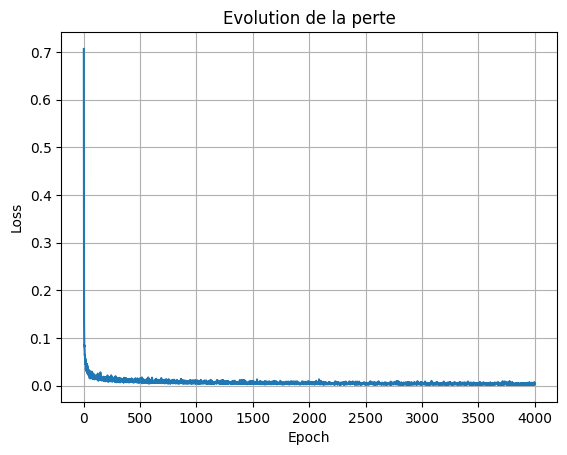

In [ ]:
plt.plot(list_epoch, list_avg_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolution de la perte')
plt.grid(True)
plt.show()

Comparing generations for model: feather_diffusionepoch500.pt
Checkpoint chargé depuis /content/drive/MyDrive/Plumes_ID/checkpoints/feather_diffusionepoch500.pt (epoch 500)
================feather_diffusionepoch500.pt=================


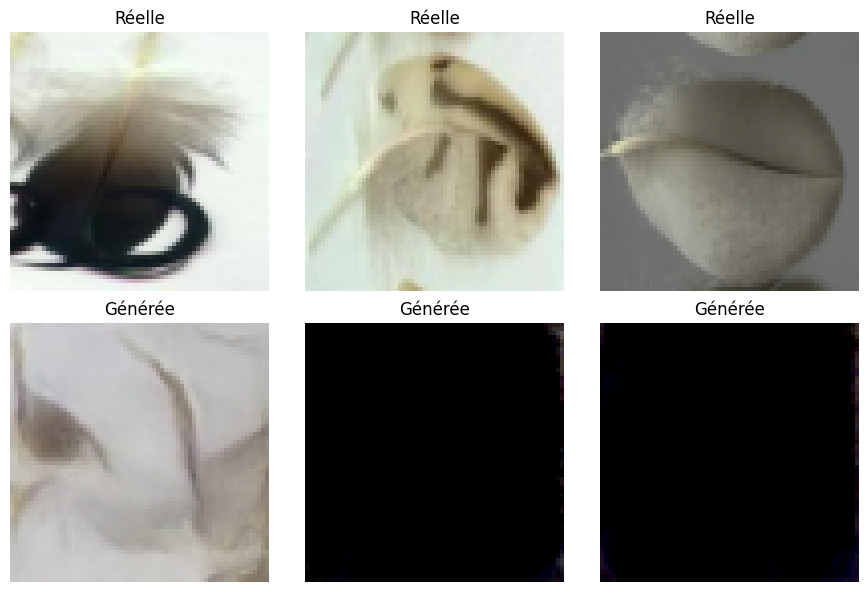

Comparing generations for model: feather_diffusionepoch1000.pt
Checkpoint chargé depuis /content/drive/MyDrive/Plumes_ID/checkpoints/feather_diffusionepoch1000.pt (epoch 1000)
================feather_diffusionepoch1000.pt=================


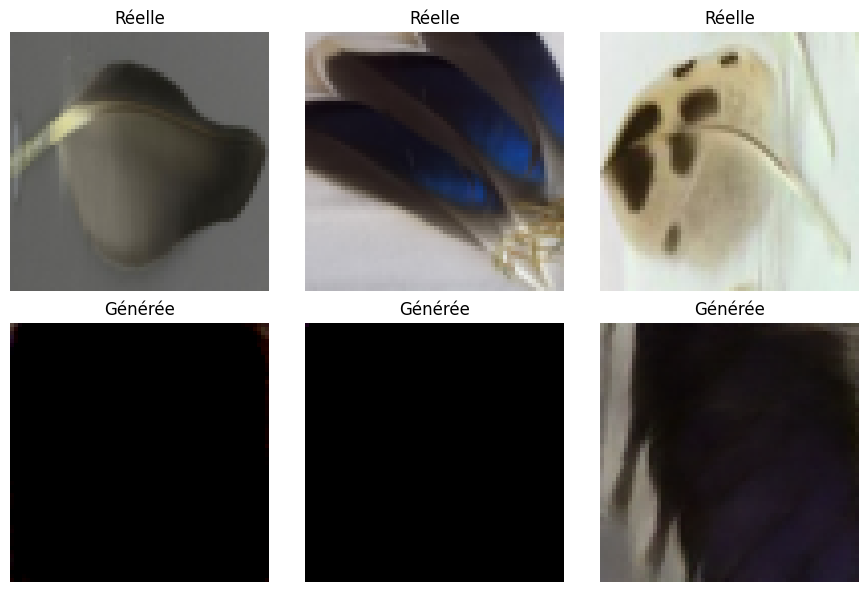

Comparing generations for model: feather_diffusionepoch1500.pt
Checkpoint chargé depuis /content/drive/MyDrive/Plumes_ID/checkpoints/feather_diffusionepoch1500.pt (epoch 1500)
================feather_diffusionepoch1500.pt=================


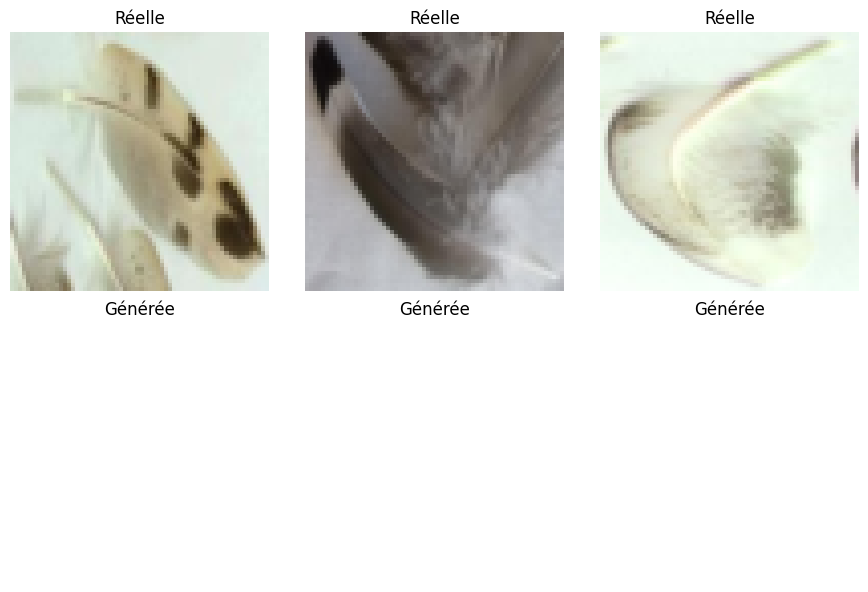

Comparing generations for model: feather_diffusionepoch2000.pt
Checkpoint chargé depuis /content/drive/MyDrive/Plumes_ID/checkpoints/feather_diffusionepoch2000.pt (epoch 2000)
================feather_diffusionepoch2000.pt=================


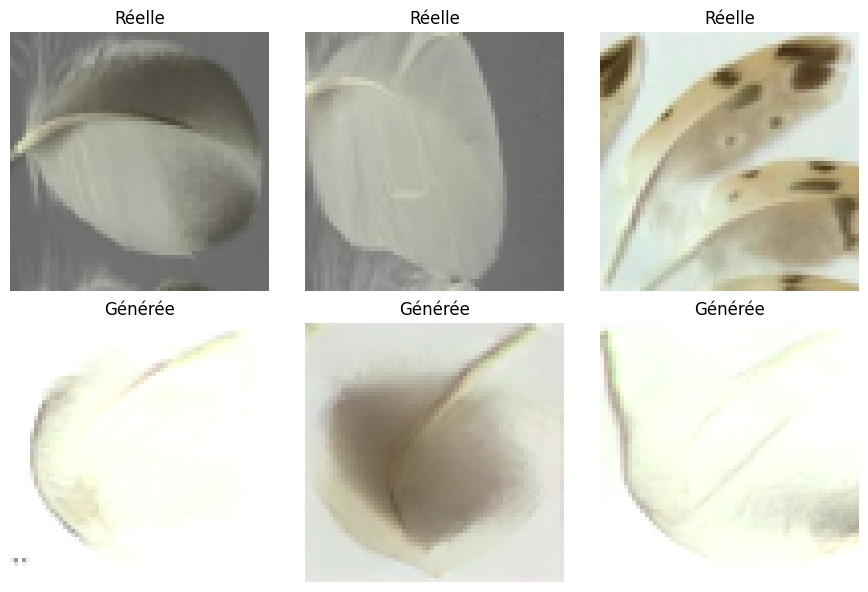

Comparing generations for model: feather_diffusionepoch2500.pt
Checkpoint chargé depuis /content/drive/MyDrive/Plumes_ID/checkpoints/feather_diffusionepoch2500.pt (epoch 2500)
================feather_diffusionepoch2500.pt=================


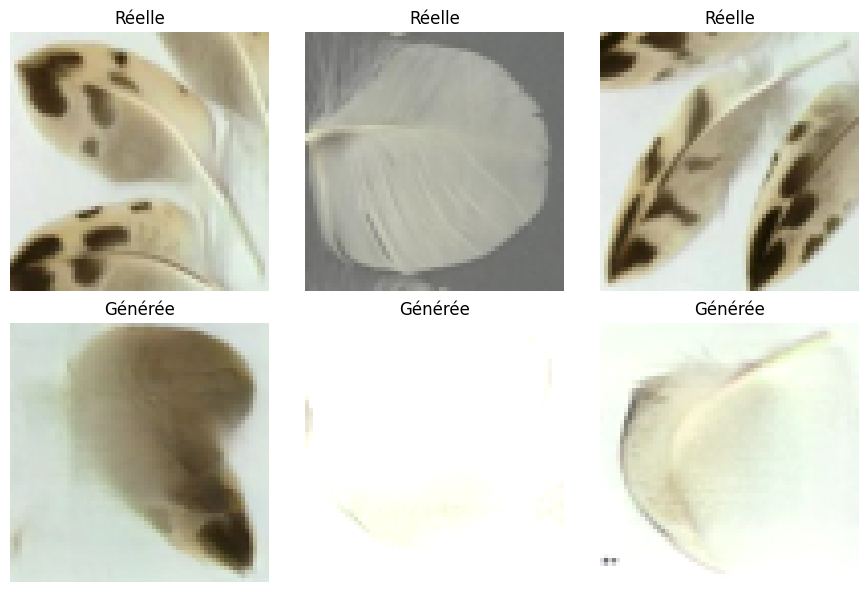

In [ ]:
def compare_model_generations_with_real(model_filename: str, num_samples_to_plot: int = 3):
    """
    Loads a specific model checkpoint, generates a batch of images,
    and compares them visually with real images from the dataset.

    Args:
        model_filename (str): The filename of the checkpoint (e.g., "feather_diffusionepoch10.pt").
        num_samples_to_plot (int): Number of real/fake image pairs to plot (max 3 for current layout).
    """
    print(f"Comparing generations for model: {model_filename}")

    # Re-instantiate the model and diffusion to ensure clean state for the specified checkpoint
    # (Assumes UNetWithAttention, Diffusion, device, num_classes, TIMESTEPS, IMAGE_SIZE are globally accessible)
    model_to_test = UNetWithAttention(
        img_channels=3,
        base_channels=64,
        time_emb_dim=256,
        num_classes=num_classes
    ).to(device)

    diffusion_to_test = Diffusion(timesteps=TIMESTEPS, device=device)

    ckpt_path = os.path.join(CHECKPOINT_DIR, model_filename)

    # Load the checkpoint using the helper function defined earlier
    # (Assumes load_checkpoint is globally accessible)
    model_to_test = load_checkpoint(model_to_test, ckpt_path)

    # Get a batch of real images from the dataloader
    # (Assumes feather_dataloader is globally accessible)
    real_batch, real_labels = next(iter(feather_dataloader))
    real_batch = real_batch.to(device)[:num_samples_to_plot]
    real_labels = real_labels.to(device)[:num_samples_to_plot]

    with torch.no_grad():
        model_to_test.eval() # Set model to evaluation mode

        # Condition on class if num_classes > 1
        if hasattr(model_to_test, "num_classes") and model_to_test.num_classes > 1:
            # Use real labels for conditional generation to match real examples
            y = real_labels
        else:
            y = None

        # Generate fake images using the loaded model
        fake_batch = diffusion_to_test.sample(
            model=model_to_test,
            image_size=IMAGE_SIZE,
            batch_size=num_samples_to_plot,
            channels=3,
            y=y
        )

    # Denormalization function (local to this function for clarity)
    def denorm(x):
        return (x.clamp(-1, 1) + 1) / 2.0

    real_vis = denorm(real_batch).cpu()
    fake_vis = denorm(fake_batch).cpu()

    fig, axes = plt.subplots(2, num_samples_to_plot, figsize=(3 * num_samples_to_plot, 6))

    for i in range(num_samples_to_plot):
        # Ensure axes is not a 1D array if num_samples_to_plot is 1
        if num_samples_to_plot == 1:
            ax_real = axes[0]
            ax_fake = axes[1]
        else:
            ax_real = axes[0, i]
            ax_fake = axes[1, i]

        ax_real.imshow(real_vis[i].permute(1, 2, 0))
        ax_real.axis("off")
        ax_real.set_title("Réelle")

        ax_fake.imshow(fake_vis[i].permute(1, 2, 0))
        ax_fake.axis("off")
        ax_fake.set_title("Générée")

    print(f"================{model_filename}=================")
    plt.tight_layout()
    plt.show()


list_model_select = [500,1000,1500,2000,2500]

for i in list_model_select:
    compare_model_generations_with_real(f"feather_diffusionepoch{i}.pt")

In [ ]:
ckpt_to_load = os.path.join(CHECKPOINT_DIR, "feather_diffusionepoch4000.pt")
model = load_checkpoint(model, ckpt_to_load)
for i in range(10):
  generate_feather_images(model, diffusion, num_images=16, class_index=None,prefix=f'feather_sample_{i}')

Checkpoint chargé depuis /content/drive/MyDrive/Plumes_ID/checkpoints/feather_diffusionepoch4000.pt (epoch 4000)
Images générées sauvegardées dans : /content/drive/MyDrive/Plumes_ID/generated_feathers/feather_sample_0.png
Images générées sauvegardées dans : /content/drive/MyDrive/Plumes_ID/generated_feathers/feather_sample_1.png
Images générées sauvegardées dans : /content/drive/MyDrive/Plumes_ID/generated_feathers/feather_sample_2.png
Images générées sauvegardées dans : /content/drive/MyDrive/Plumes_ID/generated_feathers/feather_sample_3.png
Images générées sauvegardées dans : /content/drive/MyDrive/Plumes_ID/generated_feathers/feather_sample_4.png
Images générées sauvegardées dans : /content/drive/MyDrive/Plumes_ID/generated_feathers/feather_sample_5.png
Images générées sauvegardées dans : /content/drive/MyDrive/Plumes_ID/generated_feathers/feather_sample_6.png
Images générées sauvegardées dans : /content/drive/MyDrive/Plumes_ID/generated_feathers/feather_sample_7.png
Images générées